# BEVFormer lifting, step by step 🧭
### Learned BEV queries that *ask the cameras* what is at their location

**Lifter name:** `bevformer` · **class:** `BEVFormerLifter` · **paper:** *BEVFormer* (Li et al., ECCV 2022), spatial part only (single frame; no temporal attention, as in Simple-BEV)

The previous lifters used a fixed recipe (project, read, average). BEVFormer makes the lifting **attention-based**:

* there is one learnable **query** per BEV cell (here 32×32 = 1024 queries),
* each query knows *where* it lives in the world, so it can **project a few 3D points above its cell** into every camera,
* it then runs **deformable attention** around those image locations, learning *where exactly to look* and *how much to trust each sample*,
* and it also looks at neighbouring BEV queries (BEV self-attention).

| Step | Question |
|---|---|
| 0 | Setup and data |
| 1 | BEV queries: one learnable vector per cell |
| 2 | Pillar anchors: 3D points above each cell |
| 3 | Project anchors into the cameras: reference points + which camera sees which cell |
| 4 | Deformable attention: learned offsets around a reference point |
| 5 | BEV self-attention |
| 6 | Spatial cross-attention into the images |
| 7 | One layer and the full lifter |
| 8 | Train and test |
| 9 | What did the queries learn to look at? |
| 10 | Exercises |

## Step 0: Setup and the data

> New to this repo? The notebook `tpv_lifting_step_by_step.ipynb` explains `GridSpec`, `Cameras` and the synthetic
> data in more detail. Here is the short version.

* **Ego frame:** `x` forward, `y` left, `z up` (metres). A `GridSpec` chops a box of the world into cells.
* **Cameras:** `cameras.project(points)` maps 3D ego points to pixels `(u, v)` and a depth `d`
  (*easy direction*). Going back from a pixel needs the depth (*hard direction*).
* **Data:** procedurally rendered street scenes with 4 cameras, red *vehicles* and blue *pedestrians*.
  The task is **BEV semantic segmentation**: predict the top-down class map (`0` empty, `1` vehicle, `2` pedestrian)
  from the 4 images alone. The whole camera rig is randomly rotated in every scene, so the network *has to use the calibration*.

In [1]:
import math, time, dataclasses
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

from lifting import GridSpec, Cameras, build_bev_model
from lifting.data import SceneBatch, SyntheticSceneDataset
from lifting.geometry import DepthBins
from lifting.training import BEVSegmentationTask, Trainer

torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest"})
print("torch", torch.__version__)
from lifting.lifters import BEVFormerLifter
from lifting.lifters.bevformer import BEVFormerLayer
from lifting.attention import MSDeformableAttention2D, SpatialCrossAttention
from lifting.encoders import SimpleConvEncoder

torch 2.14.1


images: (4, 4, 3, 48, 96) = (B, N cameras, 3, H, W)
BEV labels: (4, 32, 32) = (B, X, Y)


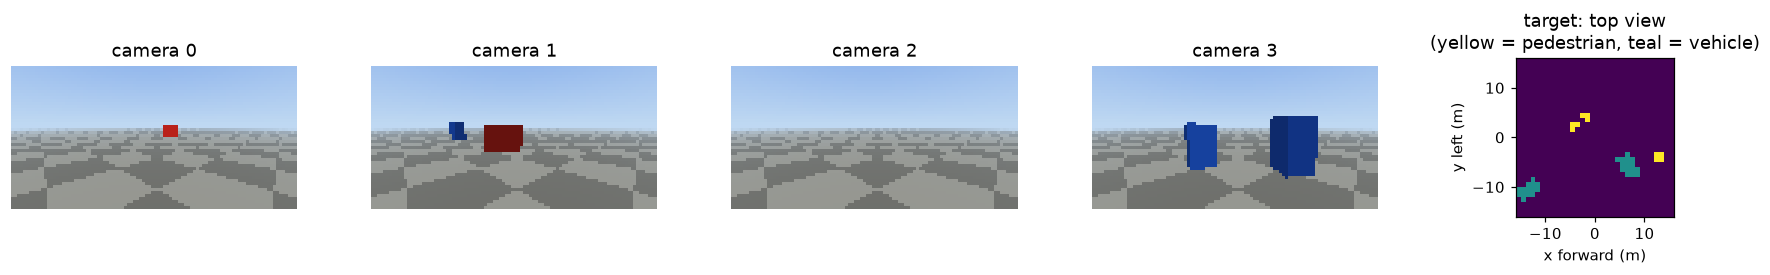

In [2]:
grid = GridSpec(resolution=(32, 32, 4))          # 32 x 32 x 4 cells of 1 m^3 over a 32 m x 32 m x 4 m box
data = SyntheticSceneDataset(256, grid, seed=1)
batch = SceneBatch.collate([data[i] for i in range(4)])
cams = batch.cameras
ext = [grid.x_bounds[0], grid.x_bounds[1], grid.y_bounds[0], grid.y_bounds[1]]
print("images:", tuple(batch.images.shape), "= (B, N cameras, 3, H, W)")
print("BEV labels:", tuple(batch.bev_labels.shape), "= (B, X, Y)")

fig, ax = plt.subplots(1, 5, figsize=(16, 2.6))
for n in range(4):
    ax[n].imshow(batch.images[0, n].permute(1, 2, 0)); ax[n].set_title(f"camera {n}"); ax[n].axis("off")
ax[4].imshow(batch.bev_labels[0].T, origin="lower", vmin=0, vmax=2, extent=ext)
ax[4].set_title("target: top view\n(yellow = pedestrian, teal = vehicle)"); ax[4].set_xlabel("x forward (m)"); ax[4].set_ylabel("y left (m)")
plt.tight_layout(); plt.show()

In [3]:
import os, sys
for _p in (".", "notebooks", os.path.join("..", "notebooks")):          # find lifting_diagrams.py next to the notebooks
    if os.path.exists(os.path.join(_p, "lifting_diagrams.py")):
        sys.path.insert(0, _p); break
import lifting_diagrams as dg

### 🖼️ Diagram: BEVFormer's mechanism
**1.** every BEV cell owns a learned query that also talks to its neighbours. **2.** The cell is a vertical pillar: 4 anchors on it are projected into the image (pure geometry).
**3.** Around each projected anchor, the query predicts a few **offsets and weights** (learned) and reads the image features there.

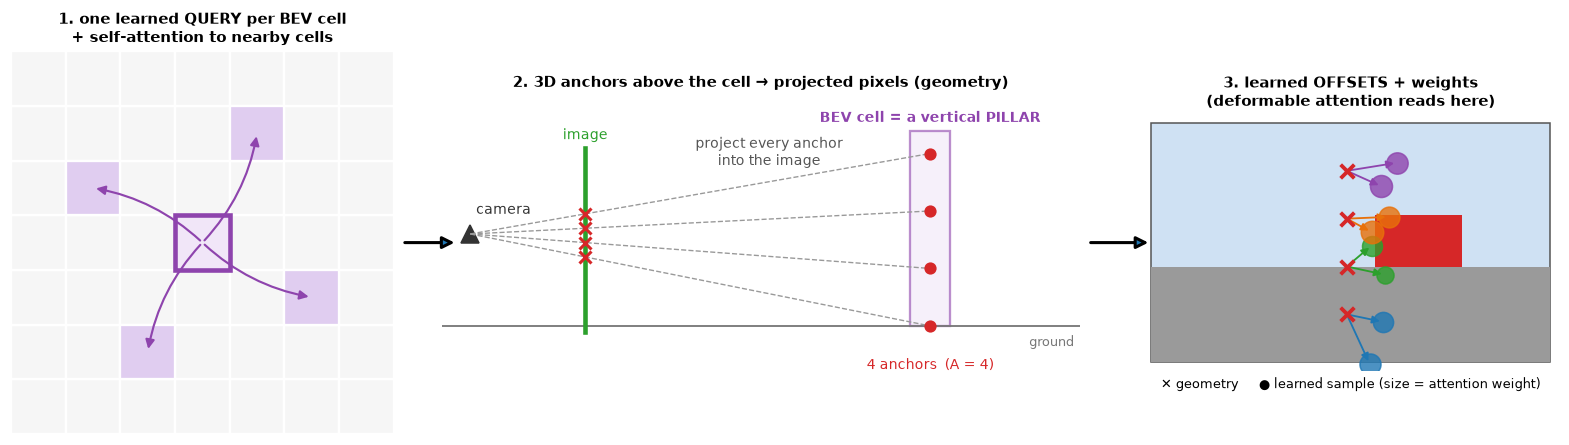

In [4]:
dg.fig_bevformer_mechanism()

## Step 1: BEV queries: one learnable vector per cell

A *query* is just a learnable `C`-vector standing for "the thing at BEV cell (x, y)". Two parameter tables are learned:
`queries` (content) and `query_pos` (a learned positional embedding). They start as small random noise. Everything the query will know about its
cell has to come from **attention into the images**.

In [5]:
lifter = BEVFormerLifter(grid, in_channels=32, out_channels=32, num_layers=2, num_levels=1, num_points=8, num_anchors=4)
print("queries   :", tuple(lifter.queries.shape), "= (X*Y cells, C)")
print("query_pos :", tuple(lifter.query_pos.shape))
print("parameters in the whole lifter:", f"{sum(p.numel() for p in lifter.parameters()):,}")
ref_bev = lifter.bev_reference_points(torch.device("cpu"))
print("\nBEV reference points (col=y, row=x in [0, 1]):", tuple(ref_bev.shape))
print("query 0   (first cell)  ->", ref_bev[0].tolist())
print("query 1023 (last cell)  ->", ref_bev[-1].tolist())

queries   : (1024, 32) = (X*Y cells, C)
query_pos : (1024, 32)
parameters in the whole lifter: 93,344

BEV reference points (col=y, row=x in [0, 1]): (1024, 2)
query 0   (first cell)  -> [0.015625, 0.015625]
query 1023 (last cell)  -> [0.984375, 0.984375]


## Step 2: Pillar anchors: lifting a 2D cell to 3D points

A BEV cell is really a **vertical pillar**, because objects at different heights all fall in the same cell. BEVFormer samples `A = 4` 3D anchors along each pillar
(`grid.pillar_points(A)` → shape `(X, Y, A, 3)`), evenly spaced between the bottom and the top of the grid.

In [6]:
pillars = grid.pillar_points(4)
print("pillar anchors:", tuple(pillars.shape), "= (X, Y, A, 3)")
print("cell (20, 16) anchors (metres):")
print(pillars[20, 16])

pillar anchors: (32, 32, 4, 3) = (X, Y, A, 3)
cell (20, 16) anchors (metres):
tensor([[ 4.5000,  0.5000, -0.5000],
        [ 4.5000,  0.5000,  0.5000],
        [ 4.5000,  0.5000,  1.5000],
        [ 4.5000,  0.5000,  2.5000]])


## Step 3: Project the anchors into every camera

`lifter.camera_reference_points(cameras)` projects all `X·Y·A` anchors into the `N` cameras. Result: where in each image each query should start looking
(`ref_cam`, normalised to `[0, 1]`) and whether the anchor is actually inside that camera's image (`visible`).

reference points: (4, 4, 1024, 4, 2) = (B, N, Q, A, 2)
visible         : (4, 4, 1024, 4) = (B, N, Q, A)


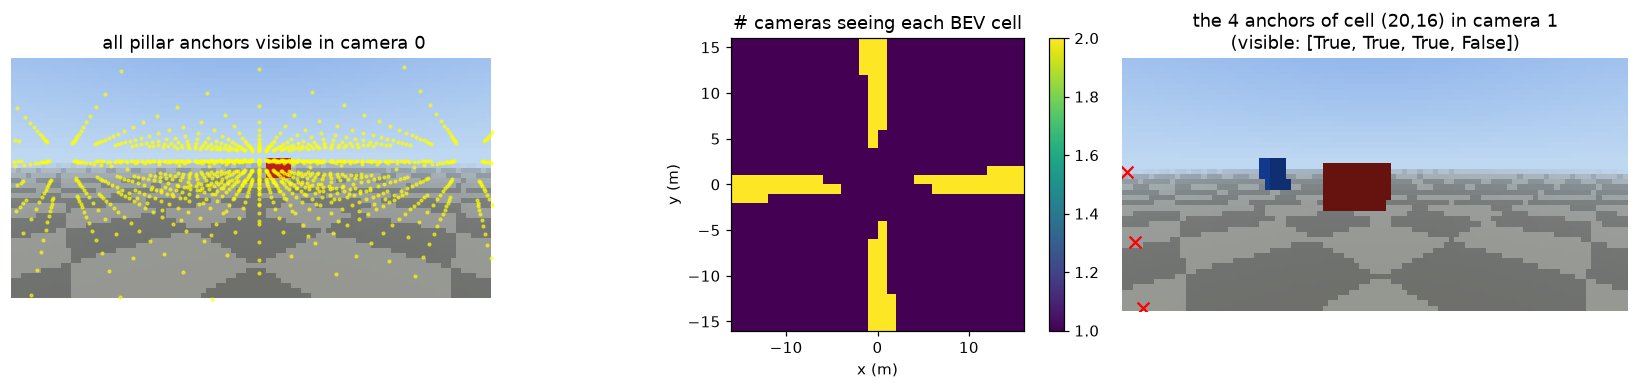

In [7]:
ref_cam, visible = lifter.camera_reference_points(cams)
print("reference points:", tuple(ref_cam.shape), "= (B, N, Q, A, 2)")
print("visible         :", tuple(visible.shape), "= (B, N, Q, A)")

seen_by = visible.any(-1).sum(1).view(4, *grid.bev_shape)          # (B, X, Y): number of cameras that see the cell
H, W = cams.image_size
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
v = visible[0, 0]
pts = (ref_cam[0, 0][v] * torch.tensor([W, H]))
ax[0].imshow(batch.images[0, 0].permute(1, 2, 0)); ax[0].scatter(pts[:, 0], pts[:, 1], s=3, c="yellow", alpha=0.6)
ax[0].set_title("all pillar anchors visible in camera 0"); ax[0].axis("off")
im = ax[1].imshow(seen_by[0].T, origin="lower", extent=ext); plt.colorbar(im, ax=ax[1], fraction=0.046); ax[1].set_title("# cameras seeing each BEV cell")
# one pillar through the 4 cameras
q = 20 * 32 + 16
ax[2].imshow(batch.images[0, 1].permute(1, 2, 0))
p = ref_cam[0, 1, q] * torch.tensor([W, H]); vis = visible[0, 1, q]
ax[2].scatter(p[vis, 0], p[vis, 1], s=60, c="red", marker="x"); ax[2].set_title(f"the 4 anchors of cell (20,16) in camera 1\n(visible: {vis.tolist()})"); ax[2].axis("off")
for a in ax[1:2]: a.set_xlabel("x (m)"); a.set_ylabel("y (m)")
plt.tight_layout(); plt.show()

A cell's **projected pillar is a short vertical streak** in the image; a cell that is seen by no camera simply attends to nothing.
These reference points are *pure geometry*, with no learning. Learning only enters when the query decides how much to deviate from them (next step).

## Step 4: Deformable attention: learn *where to look* around a reference point

Full attention over all pixels is too costly, so **deformable attention** works like this. A query `q` with reference point `p`:

1. predicts `P` **offsets** `Δp_i = Linear(q)` → sampling locations `p + Δp_i`,
2. predicts `P` **attention weights** `a_i = softmax(Linear(q))`,
3. output = `Σ a_i · value(p + Δp_i)` (bilinear read), per attention head.

At initialisation the offset layer has **zero weights** and a bias that fans the heads out in different directions, at increasing distances
(so every head already "looks around"). Here is that initial pattern for `MSDeformableAttention2D` with 4 heads × 4 points:

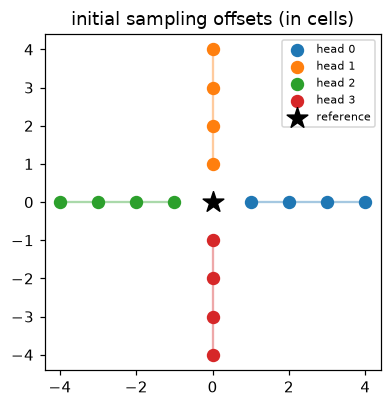

number of values the offset layer predicts per query: heads*levels*points*2 = 32


In [8]:
attn = MSDeformableAttention2D(embed_dims=32, num_heads=4, num_levels=1, num_points=4)
off = attn.sampling_offsets.bias.detach().view(4, 1, 4, 2)          # (heads, levels, points, xy) in feature-map cells
fig, ax = plt.subplots(figsize=(3.8, 3.8))
for hd in range(4):
    o = off[hd, 0]
    ax.scatter(o[:, 0], o[:, 1], s=60, label=f"head {hd}"); ax.plot(o[:, 0], o[:, 1], alpha=0.4)
ax.scatter([0], [0], c="k", marker="*", s=200, label="reference"); ax.legend(fontsize=7); ax.set_aspect("equal")
ax.set_title("initial sampling offsets (in cells)"); plt.tight_layout(); plt.show()
print("number of values the offset layer predicts per query: heads*levels*points*2 =", 4 * 1 * 4 * 2)

After training, the weights of this `Linear` are no longer 0, so **each query predicts its own offsets from its own content**. We look at
what they learned in Step 9.

## Step 5: BEV self-attention

Before looking at images, each query gathers context from nearby BEV queries (a car occupies several cells; a road continues).
This is plain `MSDeformableAttention2D` applied to the BEV query grid itself (1 level, `(X, Y)` map, reference = the cell's own position).

In [9]:
Q = grid.num_cells_bev
query = torch.randn(2, Q, 32); pos = torch.randn(2, Q, 32)
self_attn = MSDeformableAttention2D(32, num_heads=4, num_levels=1, num_points=4)
ref = lifter.bev_reference_points(query.device)[None].expand(2, -1, -1)
out = self_attn(query + pos, query, ref, [grid.bev_shape])     # queries read from the BEV query map itself
print("BEV self-attention:", tuple(query.shape), "->", tuple(out.shape))

BEV self-attention: (2, 1024, 32) -> (2, 1024, 32)


## Step 6: Spatial cross-attention into the images

This is the step that actually **reads the cameras**. For every query and every camera:

* the `A = 4` projected anchors are the reference points; each gets `P/A` learned offsets (`PillarDeformableAttention`),
* bilinear reads from the camera's feature map are mixed with learned softmax weights,
* **only cameras that see at least one of the anchors contribute**, and the result is averaged over those cameras (a cell seen by no camera gets 0).

(This module is shared with TPVFormer: see `tpv_lifting_step_by_step.ipynb` for a deeper dive.)

In [10]:
enc = SimpleConvEncoder(out_channels=32, num_levels=2)
with torch.no_grad():
    feats = [f.view(4, 4, *f.shape[1:]) for f in enc(batch.images.flatten(0, 1))]
from lifting.lifters.pyramid import flatten_pyramid
values, shapes = flatten_pyramid(feats[:1], lifter.level_embed)
print("flattened image tokens:", tuple(values.shape), "= (B, N, H*W, C),  shapes:", shapes)

sca = SpatialCrossAttention(32, 4, num_levels=1, num_points=8, num_anchors=4)
with torch.no_grad():
    out = sca(torch.randn(4, Q, 32), values, shapes, ref_cam, visible)
print("cross-attention output:", tuple(out.shape), "= one image-informed vector per BEV query")

# a cell whose 4 anchors project outside every image gets no image evidence at all
unseen = ~visible.any(-1).any(1)                    # (B, Q): seen by no camera
print("cells seen by no camera in sample 0:", int(unseen[0].sum()))

flattened image tokens: (4, 4, 288, 32) = (B, N, H*W, C),  shapes: [(12, 24)]
cross-attention output: (4, 1024, 32) = one image-informed vector per BEV query
cells seen by no camera in sample 0: 0


## Step 7: One layer and the full lifter

```
queries ──► BEV self-attention ──► +residual, LayerNorm
        ──► spatial cross-attention (cameras) ──► +residual, LayerNorm
        ──► feed-forward ──► +residual, LayerNorm
```
The lifter repeats this `num_layers` times, then reshapes the queries `(B, X·Y, C)` into a `(B, C, X, Y)` map and applies a 1×1 conv.

### 🖼️ Diagram: the whole BEVFormer lifter (single layer shown, repeated `num_layers` times)

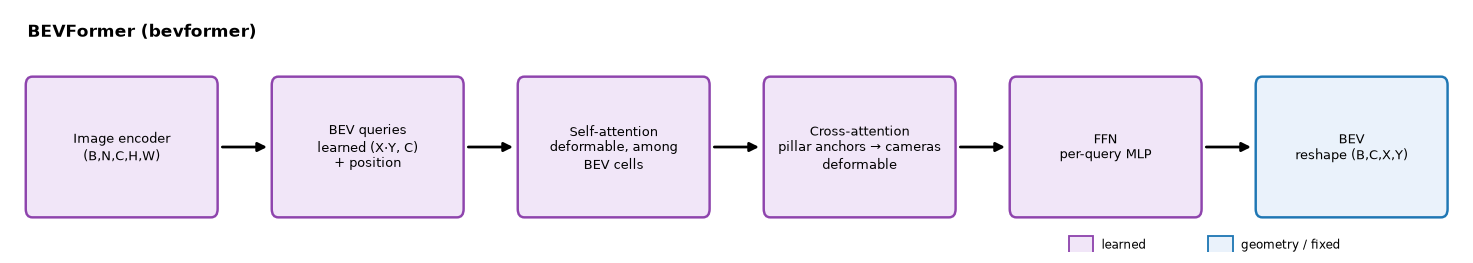

In [11]:
dg.pipeline([('Image encoder', '(B,N,C,H,W)'), ('BEV queries', 'learned (X·Y, C)\n+ position'), ('Self-attention', 'deformable, among\nBEV cells'), ('Cross-attention', 'pillar anchors → cameras\ndeformable'), ('FFN', 'per-query MLP'), ('BEV', 'reshape (B,C,X,Y)')], 'BEVFormer (bevformer)', learned=(0, 1, 2, 3, 4))

In [12]:
with torch.no_grad():
    bev = lifter(feats, cams)
print("BEV features:", tuple(bev.shape), "= (B, C, X, Y)")
n_att = sum(p.numel() for l in lifter.layers for p in l.parameters())
print(f"layers: {len(lifter.layers)}, parameters in layers: {n_att:,}, in the learned query tables: {lifter.queries.numel() + lifter.query_pos.numel():,}")

BEV features: (4, 32, 32, 32) = (B, C, X, Y)
layers: 2, parameters in layers: 26,720, in the learned query tables: 65,536


## Final step: plug it into a full model, train, and test it

`build_bev_model("bevformer", ...)` = **image encoder → `bevformer` lifter → BEV decoder (small U-Net) → segmentation head**.
Only the lifter changes between methods. Loss is weighted cross-entropy on the BEV map; the metric is the mean IoU of the two foreground classes.
Training uses 192 scenes and the score is measured on 64 **unseen** scenes.

In [13]:
torch.manual_seed(0)
def make_batches(lo, hi, bs=4):
    return [SceneBatch.collate([data[i + j] for j in range(bs)]) for i in range(lo, hi, bs)]
train_batches, test_batches = make_batches(0, 192), make_batches(192, 256)

model = build_bev_model("bevformer", grid, num_classes=3, image_size=(48, 96), num_cameras=4, channels=32)
n_total = sum(p.numel() for p in model.parameters()); n_lift = sum(p.numel() for p in model.lifter.parameters())
print(f"parameters: {n_total:,} total, {n_lift:,} in the lifter")

trainer = Trainer(model, BEVSegmentationTask(num_classes=3))
print("mIoU before training:", round(trainer.evaluate(test_batches).mean_foreground(), 3))
t0 = time.time()
trainer.fit(train_batches, steps=250)
print(f"trained 250 steps in {time.time() - t0:.0f}s")
print("mIoU after training :", round(trainer.evaluate(test_batches).mean_foreground(), 3))

parameters: 712,547 total, 93,344 in the lifter


mIoU before training: 0.014


In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(trainer.history.losses, alpha=0.3, label="per step"); plt.plot(trainer.history.smoothed(15), label="smoothed")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

tb = test_batches[0]
pred = trainer.predict(tb)
fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for s in range(4):
    ax[0, s].imshow(tb.bev_labels[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[0, s].set_title(f"scene {s}: ground truth")
    ax[1, s].imshow(pred[s].T, origin="lower", vmin=0, vmax=2, extent=ext); ax[1, s].set_title("prediction")
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### Does it really use the geometry? 🔬
Keep images and labels fixed, but **rotate the camera extrinsics by 90°**. A lifter that truly maps pixels to the world through
the calibration must now fail. (`lifting-verify` does this for every lifter.)

In [ ]:
Rz = torch.eye(4); Rz[0, 0], Rz[0, 1], Rz[1, 0], Rz[1, 1] = 0.0, -1.0, 1.0, 0.0     # 90 degrees about z
rotate_rig = lambda b: dataclasses.replace(b, cameras=b.cameras.transformed(Rz))

good = trainer.evaluate(test_batches).mean_foreground()
bad  = trainer.evaluate(test_batches, transform=rotate_rig).mean_foreground()
print(f"mIoU, correct extrinsics: {good:.3f}")
print(f"mIoU, rotated extrinsics: {bad:.3f}   -> drops by {100 * (1 - bad / max(good, 1e-9)):.0f}%")

## Step 9: Where do the queries look in the image?

Let's open up layer 0 of the trained model and compute, for one BEV cell that contains a **vehicle**, the exact sampling points of its spatial cross-attention:
the 4 projected pillar anchors (red ✕) and the learned sampling points around them (coloured by attention head; bigger dot = larger attention weight).

In [ ]:
from lifting.lifters.pyramid import flatten_pyramid
lft = model.lifter; model.eval()
with torch.no_grad():
    f = model.encode_images(tb.images)
    vals, shp = flatten_pyramid(f[:1], lft.level_embed)
    ref_cam, vis = lft.camera_reference_points(tb.cameras)
    b, Q = vals.shape[0], grid.num_cells_bev
    ref_bev = lft.bev_reference_points(vals.device)[None].expand(b, -1, -1)
    q0, pos = lft.queries[None].expand(b, -1, -1), lft.query_pos[None].expand(b, -1, -1)
    l0 = lft.layers[0]
    q = l0.norms[0](q0 + l0.self_attn(q0 + pos, q0, ref_bev, [grid.bev_shape]))       # after BEV self-attention
    pda = l0.cross_attn.deformable_attention
    Hh, Ww = shp[0]
    offs = pda.sampling_offsets(q + pos).view(b, Q, 4, 1, 8, 2) / torch.tensor([Ww, Hh])  # (heads, levels, points) -> normalised
    wts = pda.attention_weights(q + pos).view(b, Q, 4, 8).softmax(-1)

# pick a vehicle cell that some camera sees
lab = tb.bev_labels[0].flatten()
cand = [(c, qi) for qi in (lab == 1).nonzero().flatten().tolist() for c in range(4) if vis[0, c, qi].all()]
c, qi = cand[len(cand) // 2]
loc = ref_cam[0, c, qi][None, None, None, :, :] + offs[0, qi].view(4, 1, 2, 4, 2)      # (heads, levels, P/A, A, 2)
loc = (loc.reshape(4, 8, 2) * torch.tensor([96.0, 48.0]))
w = wts[0, qi]                                                                           # (heads, 8)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].imshow(tb.bev_labels[0].T, origin="lower", vmin=0, vmax=2, extent=ext)
ax[0].scatter([grid.axis_centers(0)[qi // 32]], [grid.axis_centers(1)[qi % 32]], c="r", marker="x", s=80); ax[0].set_title("the chosen BEV cell (red x)")
ax[1].imshow(tb.images[0, c].permute(1, 2, 0))
anchors = ref_cam[0, c, qi] * torch.tensor([96.0, 48.0])
ax[1].scatter(anchors[:, 0], anchors[:, 1], c="red", marker="x", s=60, label="projected pillar anchors")
for hd in range(4):
    ax[1].scatter(loc[hd, :, 0], loc[hd, :, 1], s=w[hd] * 800, alpha=0.7, label=f"head {hd}")
ax[1].legend(fontsize=6, loc="center left", bbox_to_anchor=(1.0, 0.5)); ax[1].set_title(f"where this cell looks in camera {c}"); ax[1].axis("off")
plt.tight_layout(); plt.show()
print("attention weights of head 0 (8 points):", [round(x, 3) for x in w[0].tolist()], "(uniform would be 0.125)")

**Reading the figure:** the sampling points cluster around the projected pillar (that is the geometry doing its job), and the learned offsets and weights decide the exact pattern.

An honest note: in this very short training run the offsets move only a little (a few hundredths of a cell in the BEV self-attention). The original BEVFormer trains
for many epochs and uses a smaller learning rate for the offset layers. Most of the early gain comes from the geometry-derived reference points and the value / output projections.

## Step 10: Recap and exercises

```
BEV query (learned) ─► self-attention among BEV cells
cell ─► 4 pillar anchors ─► project into every camera ─► reference points ─► deformable cross-attention ─► mean over seeing cameras
                                            ─► FFN ─► (repeat) ─► reshape to (B, C, X, Y)
```
**Pros:** no depth head, learns where to look, handles any number of cameras, scales to long ranges. **Cons:** slower than Simple-BEV; needs more data to shine;
pillars along z only (TPVFormer adds the two side planes).

### 🧪 Exercises
1. Use `build_bev_model("bevformer", ..., num_levels=2)` to read both pyramid levels (the multi-scale variant). Speed vs. mIoU?
2. Set `num_layers=1` and `num_layers=4`.
3. Change `num_anchors` from 4 to 1 and to 8 (keep `num_points` a multiple of it). What does a single anchor lose?
4. Train 5× longer and re-run Step 9. Do the sampling points move further from the pillar?
5. Compare the sampling pattern of a cell near the ego vehicle with one at the edge of the grid.